# Notebook 08 - All Model Comparison

This notebook compares **all saved models** across XPQRS and PQ Disturbances datasets using the same evaluation protocol.

## 1. Imports and Setup

In [ ]:
import os
import re
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score

sns.set_theme(style='whitegrid')
%matplotlib inline

SEED = 42
ROOT = Path('..')
MODELS_DIR = ROOT / 'results' / 'models'
TABLES_DIR = ROOT / 'results' / 'tables'
FIG_DIR = ROOT / 'results' / 'figures'
FIG_DIR.mkdir(parents=True, exist_ok=True)

XPQRS_FEATURES = TABLES_DIR / 'xpqrs_features.csv'
PQ_FEATURES = TABLES_DIR / 'pq_features.csv'
FINAL_COMPARISON_OUT = TABLES_DIR / 'final_comparison.csv'

## 2. Helper Functions

In [ ]:
# Convert model file key to a clean display name.
def pretty_model_name(name):
    name = name.replace('_', ' ').strip()
    name = re.sub(r'\s+', ' ', name)
    name = name.title()
    name = name.replace('Knn', 'KNN').replace('Svm', 'SVM')
    name = name.replace('Random Forest Tuned', 'Random Forest (Tuned)')
    return name

# Load features and split into train/test with stratification.
def load_and_split_features(csv_path, seed=SEED):
    df = pd.read_csv(csv_path)
    feature_cols = [c for c in df.columns if c != 'label']

    X = df[feature_cols].values
    X = np.nan_to_num(X, nan=0.0, posinf=0.0, neginf=0.0)

    le = LabelEncoder()
    y = le.fit_transform(df['label'])

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=seed, stratify=y
    )
    return X_train, X_test, y_train, y_test, le

# Evaluate one model file on test data and return common metrics.
def evaluate_model(model_path, X_test, y_test):
    pipe = joblib.load(model_path)
    y_pred = pipe.predict(X_test)

    return {
        'accuracy': float(accuracy_score(y_test, y_pred)),
        'f1_macro': float(f1_score(y_test, y_pred, average='macro')),
        'precision_macro': float(precision_score(y_test, y_pred, average='macro', zero_division=0)),
        'recall_macro': float(recall_score(y_test, y_pred, average='macro', zero_division=0)),
    }

## 3. Discover Available Models

In [ ]:
# Collect all saved model files for both datasets.
xpqrs_model_files = sorted(MODELS_DIR.glob('xpqrs_*.pkl'))
pq_model_files = sorted(MODELS_DIR.glob('pq_disturbances_*.pkl'))

print('XPQRS models found:')
for p in xpqrs_model_files:
    print('-', p.name)

print('\nPQ Disturbances models found:')
for p in pq_model_files:
    print('-', p.name)

## 4. Load Datasets and Build Test Splits

In [ ]:
# Prepare consistent test splits for fair model comparison.
X_train_x, X_test_x, y_train_x, y_test_x, le_x = load_and_split_features(XPQRS_FEATURES)
X_train_p, X_test_p, y_train_p, y_test_p, le_p = load_and_split_features(PQ_FEATURES)

print(f'XPQRS test shape: {X_test_x.shape}, classes: {len(le_x.classes_)}')
print(f'PQ test shape: {X_test_p.shape}, classes: {len(le_p.classes_)}')

## 5. Evaluate All Models

In [12]:
# Evaluate each dataset model and store metrics in one table.
xpqrs_results = {}
for p in xpqrs_model_files:
    key = p.stem.replace('xpqrs_', '')
    xpqrs_results[key] = evaluate_model(p, X_test_x, y_test_x)

pq_results = {}
for p in pq_model_files:
    key = p.stem.replace('pq_disturbances_', '')
    pq_results[key] = evaluate_model(p, X_test_p, y_test_p)

all_model_keys = sorted(set(xpqrs_results.keys()) | set(pq_results.keys()))
rows = []
for k in all_model_keys:
    x = xpqrs_results.get(k, {})
    p = pq_results.get(k, {})
    rows.append({
        'Model': pretty_model_name(k),
        'XPQRS Accuracy': x.get('accuracy'),
        'PQ Accuracy': p.get('accuracy'),
        'XPQRS F1': x.get('f1_macro'),
        'PQ F1': p.get('f1_macro'),
        'XPQRS Precision': x.get('precision_macro'),
        'PQ Precision': p.get('precision_macro'),
        'XPQRS Recall': x.get('recall_macro'),
        'PQ Recall': p.get('recall_macro'),
    })

comparison_df = pd.DataFrame(rows).sort_values(by='XPQRS Accuracy', ascending=False, na_position='last')
display(comparison_df)

,Model,XPQRS Accuracy,PQ Accuracy,XPQRS F1,PQ F1,XPQRS Precision,PQ Precision,XPQRS Recall,PQ Recall
1,Gradient Boosting,0.911176,0.98125,0.910718,0.980488,0.911244,0.982372,0.911176,0.980507
4,Random Forest,0.906176,0.98125,0.905569,0.981554,0.906731,0.983333,0.906176,0.981583
5,Random Forest (Tuned),0.905588,NaN,0.904936,NaN,0.906390,NaN,0.905588,NaN
0,Decision Tree,0.865000,0.96250,0.864631,0.962010,0.865031,0.965934,0.865000,0.961680
3,Logistic Regression,0.852353,0.93750,0.848897,0.937196,0.850211,0.946407,0.852353,0.936612
6,SVM,0.833529,0.88125,0.829813,0.879784,0.833868,0.899016,0.833529,0.879754
2,KNN,0.800588,0.90625,0.795468,0.904601,0.805565,0.914417,0.800588,0.908425


## 6. Save Comparison Table

In [ ]:
# Save final comparison table for reports and README usage.
comparison_df.to_csv(FINAL_COMPARISON_OUT, index=False)
print(f'Saved: {FINAL_COMPARISON_OUT}')

## 7. Plot Accuracy Comparison

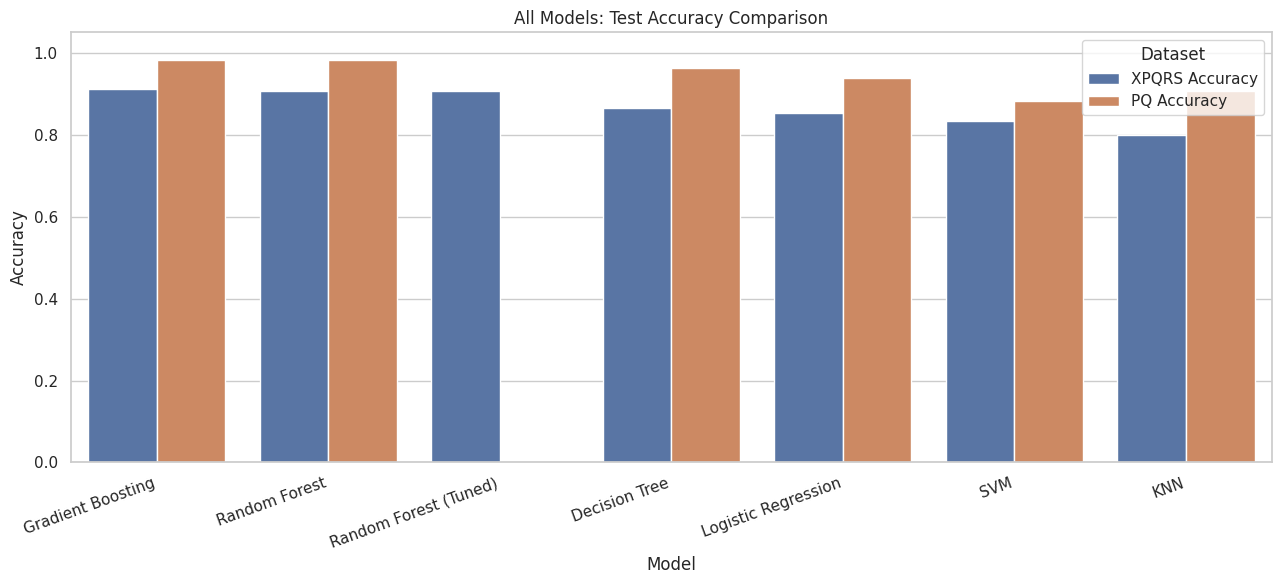

In [10]:
# Draw grouped bars for XPQRS vs PQ test accuracy by model.
plot_df = comparison_df[['Model', 'XPQRS Accuracy', 'PQ Accuracy']].copy()
melt_acc = plot_df.melt(id_vars='Model', var_name='Dataset', value_name='Accuracy').dropna()

plt.figure(figsize=(13, 6))
sns.barplot(data=melt_acc, x='Model', y='Accuracy', hue='Dataset')
plt.title('All Models: Test Accuracy Comparison')
plt.ylim(0, 1.05)
plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.savefig(FIG_DIR / 'all_models_accuracy_comparison.png', dpi=160, bbox_inches='tight')
plt.show()

## 8. Plot F1-Macro Comparison

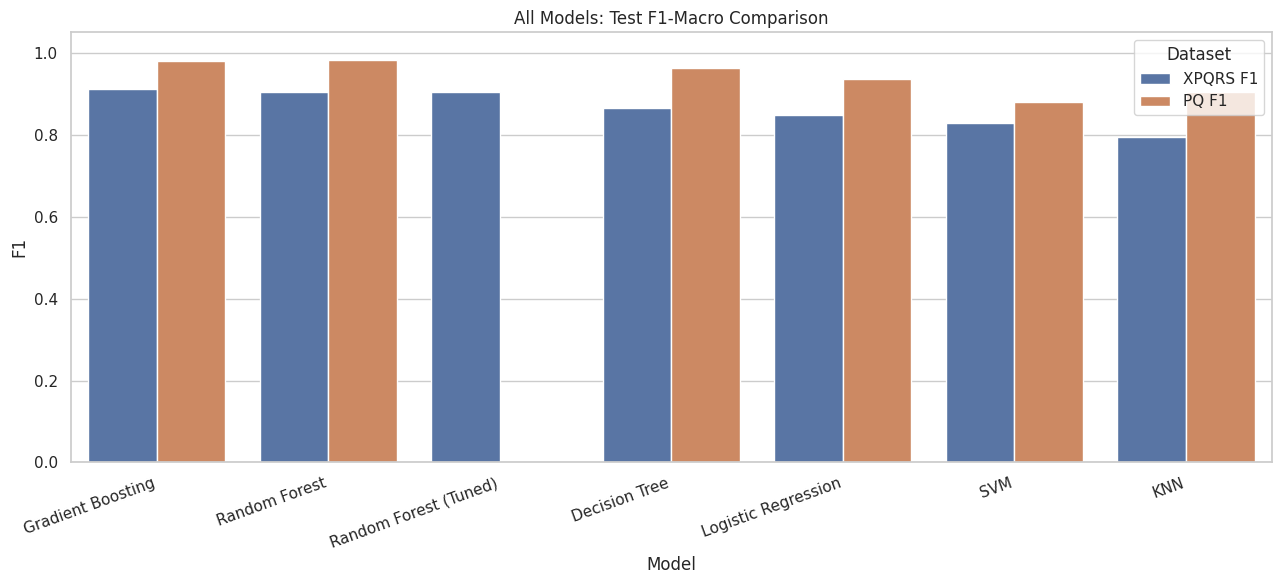

In [11]:
# Draw grouped bars for XPQRS vs PQ macro-F1 by model.
plot_df = comparison_df[['Model', 'XPQRS F1', 'PQ F1']].copy()
melt_f1 = plot_df.melt(id_vars='Model', var_name='Dataset', value_name='F1').dropna()

plt.figure(figsize=(13, 6))
sns.barplot(data=melt_f1, x='Model', y='F1', hue='Dataset')
plt.title('All Models: Test F1-Macro Comparison')
plt.ylim(0, 1.05)
plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.savefig(FIG_DIR / 'all_models_f1_comparison.png', dpi=160, bbox_inches='tight')
plt.show()

## 9. Best Model Summary

In [ ]:
# Print best models by dataset-specific metrics for quick discussion.
best_x_acc = comparison_df.dropna(subset=['XPQRS Accuracy']).sort_values('XPQRS Accuracy', ascending=False).iloc[0]
best_p_acc = comparison_df.dropna(subset=['PQ Accuracy']).sort_values('PQ Accuracy', ascending=False).iloc[0]
best_x_f1 = comparison_df.dropna(subset=['XPQRS F1']).sort_values('XPQRS F1', ascending=False).iloc[0]
best_p_f1 = comparison_df.dropna(subset=['PQ F1']).sort_values('PQ F1', ascending=False).iloc[0]

print('Best XPQRS Accuracy:', best_x_acc['Model'], f"({best_x_acc['XPQRS Accuracy']:.4f})")
print('Best PQ Accuracy   :', best_p_acc['Model'], f"({best_p_acc['PQ Accuracy']:.4f})")
print('Best XPQRS F1      :', best_x_f1['Model'], f"({best_x_f1['XPQRS F1']:.4f})")
print('Best PQ F1         :', best_p_f1['Model'], f"({best_p_f1['PQ F1']:.4f})")